In [23]:
import pandas as pd

In [24]:
df = pd.read_csv('data/final_dataset_sampled.csv')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379225 entries, 0 to 379224
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   tag_name              379225 non-null  object
 1   article_id            379225 non-null  int64 
 2   source_feed_name      379225 non-null  object
 3   load_date             379225 non-null  object
 4   feed_name             379225 non-null  object
 5   author_name           379225 non-null  object
 6   source_unique_id      379225 non-null  object
 7   source_type_name      379225 non-null  object
 8   channel_name          379225 non-null  object
 9   genre                 379225 non-null  object
 10  publisher_name        379225 non-null  object
 11  publication_name      379225 non-null  object
 12  circulation_size      379225 non-null  int64 
 13  sentiment_score       379225 non-null  int64 
 14  source_type           379225 non-null  object
 15  sentiment_band   

In [26]:
df.head()

,tag_name,article_id,source_feed_name,load_date,feed_name,author_name,source_unique_id,source_type_name,channel_name,genre,...,sentiment_score,source_type,sentiment_band,hit_strength,vipr_weight,vipr_score,processed_headline,processed_body,headline_token_count,body_token_count
0,Public Health,18083066685,regionals-web,2024-03-25,opoint,Jamie DeLine,31229-477204,Regional News,Web,Unknown,...,-7,Regional News,Neutral,2,685,-4795,lawmaker call independent report ny pandemic r...,albany news new york state capitol monday lost...,7,237
1,Public Health,18083068112,regionals-web,2024-03-25,opoint,Katherine Itoh,21944-341746,Regional News,Web,Unknown,...,-3,Regional News,Neutral,3,1300,-3900,yellowstone star forrie smith say kicked fligh...,forrie smith vocal public health belief skippe...,12,227
2,Public Health,18083069120,trade-web,2024-03-25,opoint,uncredited,156350-188089,Trade News,Web,Unknown,...,7,Trade News,Neutral,13,2418,16926,free rsv immunisation program queensland infan...,joint statement premier honourable steven mile...,8,571
3,Public Health,18083073191,broadcast-tv,2024-03-25,tveyes,uncredited,a7a238b1-8e47-43f1-b27d-db271714b0e9,TV,Broadcast,WFTX,...,-39,TV,Negative,2,133,-5187,fox news,local news sport weather dark purple state one...,2,321
4,Public Health,18083073192,broadcast-tv,2024-03-25,tveyes,uncredited,36c13958-e8cf-4b90-9713-4c3838eed8f4,TV,Broadcast,WFTXBACK,...,-39,TV,Negative,2,133,-5187,fox news,local news sport weather dark purple state one...,2,321



=== hit_strength vs hit_strength_log ===
Raw: {'count': 379225, 'mean': np.float64(3.354), 'std': np.float64(3.64), 'min': np.int64(0), 'max': np.int64(204), 'skew': np.float64(7.318), 'kurtosis': np.float64(176.465)}
Log: {'count': 379225, 'mean': np.float64(1.287), 'std': np.float64(0.554), 'min': np.float64(0.0), 'max': np.float64(5.323), 'skew': np.float64(0.977), 'kurtosis': np.float64(0.82)}


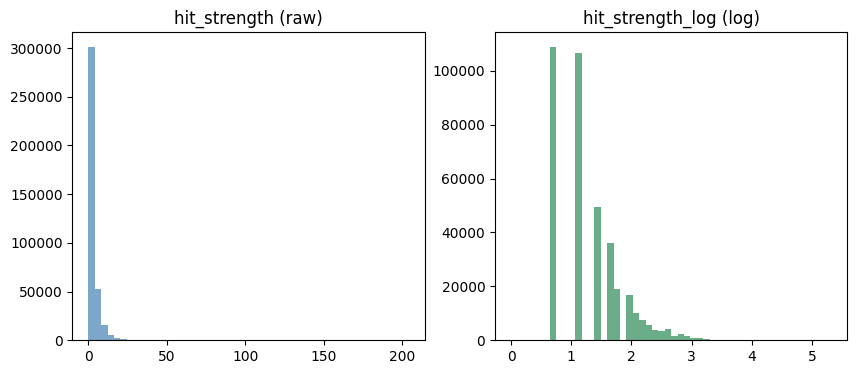


=== vipr_weight vs vipr_weight_log ===
Raw: {'count': 379225, 'mean': np.float64(706.999), 'std': np.float64(651.433), 'min': np.int64(20), 'max': np.int64(20000), 'skew': np.float64(5.243), 'kurtosis': np.float64(75.566)}
Log: {'count': 379225, 'mean': np.float64(6.22), 'std': np.float64(0.887), 'min': np.float64(3.045), 'max': np.float64(9.904), 'skew': np.float64(-0.618), 'kurtosis': np.float64(0.993)}


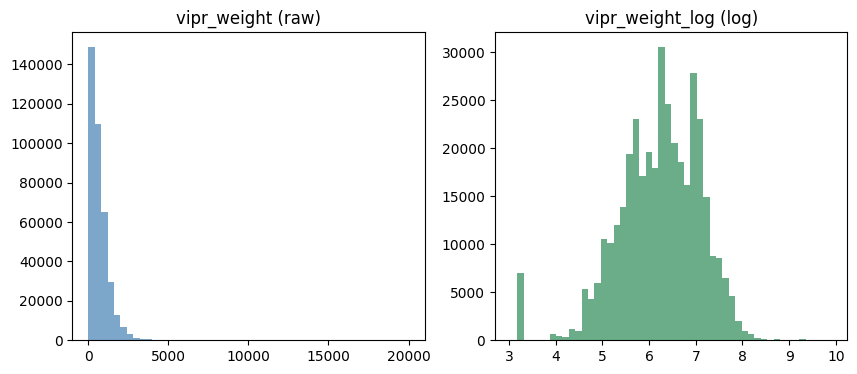


=== circulation_size vs circulation_size_log ===
Raw: {'count': 379225, 'mean': np.float64(2289232.418), 'std': np.float64(20699765.271), 'min': np.int64(1), 'max': np.int64(428640966), 'skew': np.float64(16.33), 'kurtosis': np.float64(305.48)}
Log: {'count': 379225, 'mean': np.float64(9.665), 'std': np.float64(3.017), 'min': np.float64(0.693), 'max': np.float64(19.876), 'skew': np.float64(0.675), 'kurtosis': np.float64(-0.344)}


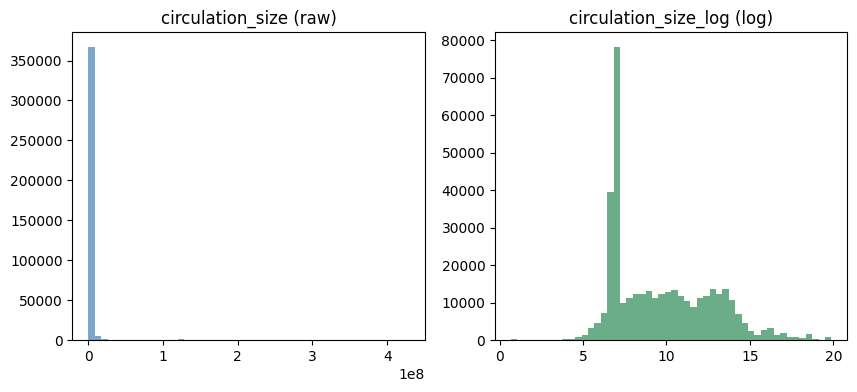


=== vipr_score vs vipr_score_clip ===
Raw: {'count': 379225, 'mean': np.float64(-6457.428), 'std': np.float64(25876.261), 'min': np.int64(-1040000), 'max': np.int64(440000), 'skew': np.float64(-3.734), 'kurtosis': np.float64(76.7)}
Log: {'count': 379225, 'mean': np.float64(-6234.891), 'std': np.float64(21651.52), 'min': np.float64(-88923.2), 'max': np.float64(54978.0), 'skew': np.float64(-0.951), 'kurtosis': np.float64(3.177)}


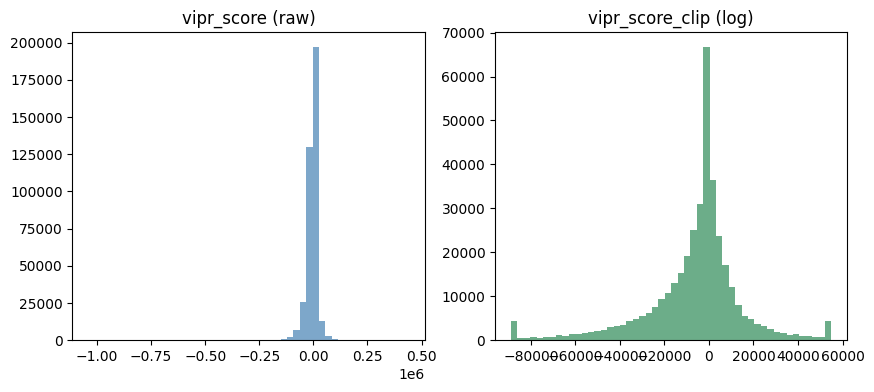

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

raw_vars = ["hit_strength", "vipr_weight", "circulation_size", "vipr_score"]``
log_vars = ["hit_strength_log", "vipr_weight_log", "circulation_size_log", "vipr_score_clip"]  

def compare_variables(df, raw_vars, log_vars):
    for raw, log in zip(raw_vars, log_vars):
        if raw not in df.columns or log not in df.columns:
            print(f"\n[Skipped: missing {raw} or {log}]")
            continue

        raw_vals = df[raw].dropna()
        log_vals = df[log].dropna()

        # --- summary statistics ---
        def summary(x):
            return {
                "count": len(x),
                "mean": round(x.mean(), 3),
                "std": round(x.std(), 3),
                "min": round(x.min(), 3),
                "max": round(x.max(), 3),
                "skew": round(skew(x), 3),
                "kurtosis": round(kurtosis(x), 3),
            }

        print(f"\n=== {raw} vs {log} ===")
        print("Raw:", summary(raw_vals))
        print("Log:", summary(log_vals))

        # --- plots ---
        fig, axes = plt.subplots(1, 2, figsize=(10,4))
        axes[0].hist(raw_vals, bins=50, color="steelblue", alpha=0.7)
        axes[0].set_title(f"{raw} (raw)")
        axes[1].hist(log_vals, bins=50, color="seagreen", alpha=0.7)
        axes[1].set_title(f"{log} (log)")
        plt.show()

# Run the comparison
compare_variables(df, raw_vars, log_vars)

## STILL NEED THE LOG

In [7]:
# % missing and % unique values
missing = df.isna().mean().sort_values(ascending=False)
unique_counts = df.nunique().sort_values(ascending=True)

print("Missingness:\n", missing.head(10))
print("\nUnique counts:\n", unique_counts.head(10))

Missingness:
 processed_headline      0.008378
processed_body          0.004731
tag_name                0.000000
engagement              0.000000
body_token_count        0.000000
headline_token_count    0.000000
vipr_score_clip         0.000000
circulation_size_log    0.000000
hit_strength_log        0.000000
vipr_weight_log         0.000000
dtype: float64

Unique counts:
 engagement            1
sentiment_band        3
tag_name              5
channel_name          5
feed_name            14
source_type_name     17
source_type          17
source_feed_name     27
hit_strength        107
hit_strength_log    107
dtype: int64


In [8]:
df.head()

,tag_name,article_id,source_feed_name,load_date,feed_name,author_name,source_unique_id,source_type_name,channel_name,genre,...,vipr_score,vipr_weight_log,hit_strength_log,circulation_size_log,vipr_score_clip,processed_headline,processed_body,headline_token_count,body_token_count,token_count
0,Public Health,18083066685,regionals-web,2024-03-25,opoint,Jamie DeLine,31229-477204,Regional News,Web,Unknown,...,-4795,6.530878,1.098612,12.459982,-4795.0,lawmaker call independent report ny pandemic r...,albany news new york state capitol monday lost...,7,237,244
1,Public Health,18083068112,regionals-web,2024-03-25,opoint,Katherine Itoh,21944-341746,Regional News,Web,Unknown,...,-3900,7.170888,1.386294,14.320644,-3900.0,yellowstone star forrie smith say kicked fligh...,forrie smith vocal public health belief skippe...,12,227,239
2,Public Health,18083069120,trade-web,2024-03-25,opoint,uncredited,156350-188089,Trade News,Web,Unknown,...,16926,7.791110,2.639057,10.310917,16926.0,free rsv immunisation program queensland infan...,joint statement premier honourable steven mile...,8,571,579
3,Public Health,18083073191,broadcast-tv,2024-03-25,tveyes,uncredited,a7a238b1-8e47-43f1-b27d-db271714b0e9,TV,Broadcast,WFTX,...,-5187,4.897840,1.098612,11.970945,-5187.0,fox news,local news sport weather dark purple state one...,2,321,323
4,Public Health,18083073192,broadcast-tv,2024-03-25,tveyes,uncredited,36c13958-e8cf-4b90-9713-4c3838eed8f4,TV,Broadcast,WFTXBACK,...,-5187,4.897840,1.098612,6.734592,-5187.0,fox news,local news sport weather dark purple state one...,2,321,323


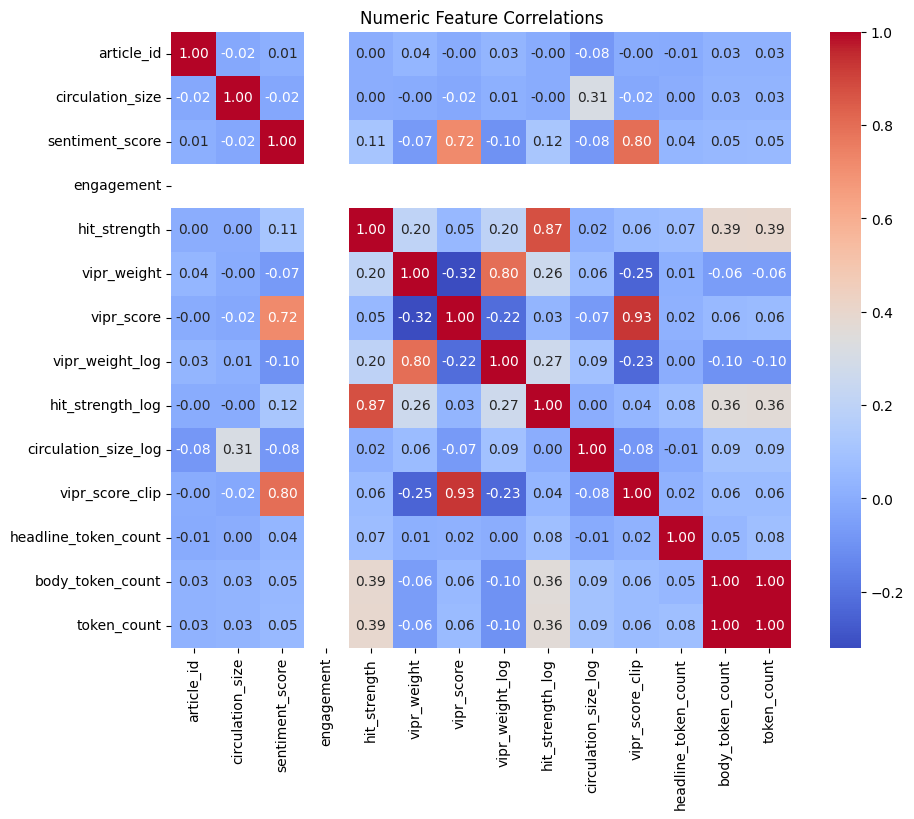

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=["int64","float64"]).columns
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Numeric Feature Correlations")
plt.show()

In [13]:
df["engagement"].unique()      # ✅ returns an array of unique values
df["engagement"].nunique()     # ✅ returns count of unique values
df["engagement"].value_counts()[:10]  # ✅ quick frequency peek

engagement
0    379225
Name: count, dtype: int64